In [53]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from typing import TypedDict

In [54]:
class BatsmanState(TypedDict):

    runs: int 
    balls: int
    fours: int
    sixes: int

    sr: float
    bpb: float
    boundary_percent: float
    Summary: str

In [55]:
def calculate_Sr(state: BatsmanState) -> BatsmanState:

    sr = (state['runs']/state['balls'])*100
    return {'sr':sr}

In [56]:
def calculate_bpb(state: BatsmanState) -> BatsmanState:

    bpb = state['balls']/(state['fours']+state['sixes'])
    return {'bpb':bpb}

    

In [57]:
def calculate_boundary_percent(state: BatsmanState) -> BatsmanState:

    boundary_percent = (((state['fours'] * 4) +(state['sixes'] * 6))/state['runs'])*100

    return {'boundary_percent':boundary_percent}

In [58]:
def Summary(state: BatsmanState) -> BatsmanState:

    Summary = f"""
Strike Rate - {state['sr']} \n
Balls per Boundary - {state['bpb']} \n
Boundary percent - {state['boundary_percent']}
"""
    return {'Summary':Summary}

In [59]:
graph = StateGraph(BatsmanState)

graph.add_node('calculate_Sr', calculate_Sr)
graph.add_node('calculate_bpb', calculate_bpb)
graph.add_node('calculate_boundary_percent', calculate_boundary_percent)
graph.add_node('Summary', Summary)

graph.add_edge(START,'calculate_Sr')
graph.add_edge(START,'calculate_bpb')
graph.add_edge(START,'calculate_boundary_percent')

graph.add_edge('calculate_Sr', 'Summary')
graph.add_edge('calculate_bpb', 'Summary')
graph.add_edge('calculate_boundary_percent', 'Summary')

graph.add_edge('Summary',END)

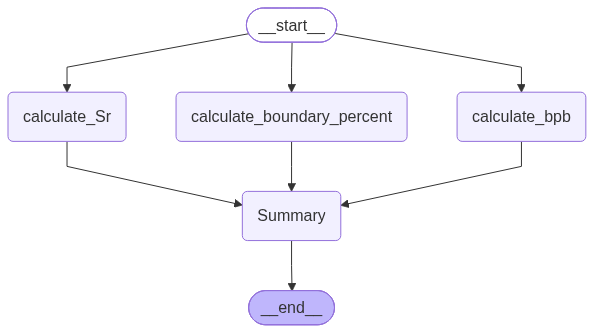

In [60]:
workflow = graph.compile()
workflow

In [61]:
initial_state = {
    'runs': 100,
    'balls': 50,
    'fours': 6,
    'sixes': 4
}

workflow.invoke(initial_state)

{'runs': 100,
 'balls': 50,
 'fours': 6,
 'sixes': 4,
 'sr': 200.0,
 'bpb': 5.0,
 'boundary_percent': 48.0,
 'Summary': '\nStrike Rate - 200.0 \n\nBalls per Boundary - 5.0 \n\nBoundary percent - 48.0\n'}